<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/AutoEncoders/Pytorch_AutoEncoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
import numpy as np
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([transforms.ToTensor()]) # tensör 0 ile 1 aralığına sıkıştırır
train_dataset = datasets.FashionMNIST(root="./data",train=True,transform=transform,download=True)
test_dataset = datasets.FashionMNIST(root="./data",train=False,transform=transform,download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.62MB/s]


In [3]:
batch_size = 128
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

In [4]:
class AutoEncoder(nn.Module):
  def __init__(self):
    super(AutoEncoder,self).__init__()
    # ENCODER => HERHANGİ BİR OUTPUT DURUMU YOK AUTOENCODER ELDE ETMEYE ÇALIŞIYORUZ.
    self.encoder = nn.Sequential(
        nn.Flatten(),# 28x28 => vektör
        nn.Linear(28*28,256), # 784 => 256
        nn.ReLU(),
        nn.Linear(256,64),
        nn.ReLU()
        )
    # DECODER
    self.decoder = nn.Sequential(
        nn.Linear(64,256), # Decoder da encoderda küçülttüğümüz veriyi decoderda genişletiriz.
        nn.ReLU(),
        nn.Linear(256,28*28),
        nn.Sigmoid(), # burda sigmoid kullandık çünkü 0-1 aralığına tensör ile sıkıştırmıştık.Sigmoidte 0-1 aralığına sıkıştırır.
        nn.Unflatten(1,(1,28,28))# Burda bizim tekrar görünütüyü elde etmemiz lazım flatten ile 784 lük bir vektör elde etmiştik 2D yi 1D lik vektöre çevirmiştik şimdi tam tersini yapacağız.
    )
  def forward(self,x):
    encoded = self.encoder(x) # giriş verisini kodlar
    decoded = self.decoder(encoded) # kodlanmış veriyi tekrar görüntüye çevirir
    return decoded

In [5]:
model = AutoEncoder()

In [6]:
# callback => early stopping
class EarlyStopping():
  def __init__(self,patience=5,min_delta=0.001):
    # kaç epoch boyunca gelişme olmazsa durduracağımızı belirleyen parametre
    self.patience = patience
    # kayıptaki minimum iyileşme miktarı
    self.min_delta = min_delta
    # en iyi kayıp değeri saklanır.
    self.best_loss = None
    # sabit kalan epoch counterı yapılır.
    self.counter = 0

  def __call__(self,loss):
    if self.best_loss is None or loss< self.best_loss - self.min_delta: # gelişme var
      self.best_loss = loss
      self.counter = 0
    else: # gelişme yoksa sayaç arttırılır.
      self.counter += 1
    if self.counter >= self.patience: # sabit kalan epoch sayısı patience'ı aşarsa
      return True # trainingi durdur
    return False

In [7]:
# model training
# hyperparameters
epochs = 50
learning_rate = 0.001
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)
early_stopping = EarlyStopping(patience=3,min_delta=0.001)

def training(model,train_loader,optimizer,criterion,early_stopping,epochs):
  model.train()
  for epoch in range(epochs):
    total_loss = 0 # epoch başına toplam kayıp
    for inputs,_ in train_loader:
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs,inputs)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    avg_loss = total_loss/len(train_loader) # epoch başına ortalama kayıp
    print(f"Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.5f}")

    # early stopping
    if early_stopping(avg_loss):
      print(f"Early stopping at epoch {epoch+1}")
      break

training(model,train_loader,optimizer,criterion,early_stopping,epochs)

Epoch 1/50, Loss : 0.03346
Epoch 2/50, Loss : 0.01756
Epoch 3/50, Loss : 0.01480
Epoch 4/50, Loss : 0.01324
Epoch 5/50, Loss : 0.01226
Epoch 6/50, Loss : 0.01158
Epoch 7/50, Loss : 0.01104
Epoch 8/50, Loss : 0.01066
Epoch 9/50, Loss : 0.01028
Epoch 10/50, Loss : 0.01000
Epoch 11/50, Loss : 0.00972
Epoch 12/50, Loss : 0.00950
Early stopping at epoch 12


In [10]:
from scipy.ndimage import gaussian_filter
def compute_ssim(img1,img2,sigma=1.5):
  C1 = (0.01*255)**2 # ssim sabitlerinden biri
  C2 = (0.03*255)**2 # diğer bir sabit

  img1 = img1.astype(np.float64)
  img2 = img2.astype(np.float64)
  # görüntülerin ortalamaları
  mu1 = gaussian_filter(img1,sigma)
  mu2 = gaussian_filter(img2,sigma)

  mu1_sq = mu1**2 # ilk görüntünün ortalamasının karesi
  mu2_sq = mu2**2
  mu1_mu2 = mu1*mu2

  sigma1_sq = gaussian_filter(img1**2,sigma)-mu1_sq # varyans hesabı
  sigma2_sq = gaussian_filter(img2**2,sigma)-mu2_sq
  sigma12 = gaussian_filter(img1*img2,sigma)-mu1_mu2 # kovaryans hesabı

  # ssim haritası hesaplama
  ssim_map = ((2*mu1_mu2+C1)*(2*sigma12+C2))/((mu1_sq+mu2_sq+C1)*(sigma1_sq+sigma2_sq+C2))
  return ssim_map.mean()

# model testing
def evaluate(model,test_loader,n_images=10):
  model.eval()
  with torch.no_grad():
    for batch in test_loader:
      inputs, _ = batch
      outputs = model(inputs)
      break
  inputs = inputs.numpy()
  outputs = outputs.numpy()

  fig,axes = plt.subplots(2,n_images,figsize=(n_images,3))
  ssim_scores = [] # ssim=> iki görüntü arasındaki benzerlik oranı 1 ise tıpatıp aynı 0 a yakın ise benzerlik yok

  for i in range(n_images):

    img1 = np.squeeze(inputs[i]) # orjinal görüntüyü sıkıştırma işlemi
    img2 = np.squeeze(outputs[i]) # yeniden oluşturulmuş görüntüleri sıkıştır

    ssim_score = compute_ssim(img1,img2)
    ssim_scores.append(ssim_score)

    axes[0,i].imshow(img1,cmap="gray")
    axes[0,i].axis("off")
    axes[1,i].imshow(img2,cmap="gray")
    axes[1,i].axis("off")

  axes[0,0].set_title("Original")
  axes[1,0].set_title("Decoded Image")
  plt.show()
  avg_ssim = np.mean(ssim_scores)
  print(f"Avarage SSIM : {avg_ssim}")

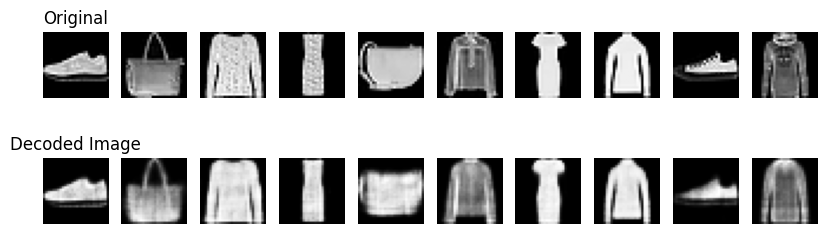

Avarage SSIM : 0.999744567320386


In [11]:
evaluate(model,test_loader,n_images=10)